In [38]:
import numpy as np
import matplotlib.pyplot as plt

### 12.5: Is the CPR Number Valid?


In [11]:
def cpr_check(array):
    control_number = np.array([4,3,2,7,6,5,4,3,2])

    # summen = np.sum(control_number * array[0:9])

    # rest = summen % 11

    # tjek = 11 - rest

    # return tjek == array[9]

    return (11 - (np.sum(control_number * array[0:9]) % 11)) == array[-1] 


    


print(cpr_check([1,1,1,1,1,1,1,1,1,8]))

True


### 12.6: Growth Curve of Bacteria

/Users/jacobiversen/Documents/TA_programmering/wekk_12


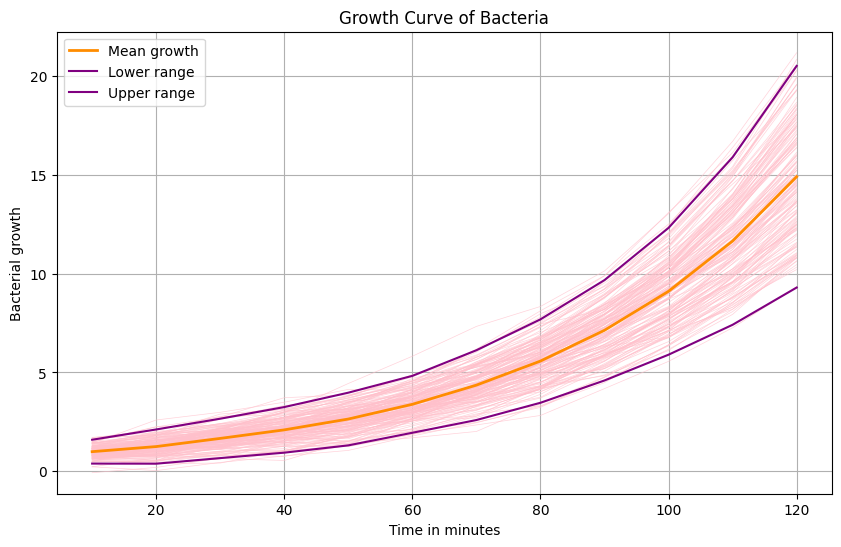

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import os
cwd = os.getcwd()
print(cwd)

path = os.path.join(cwd, 'bacteria.npy')

data = np.load(path)


time = np.arange(10, 121, 10) # array med tidsintervallerne

mean_list = np.mean(data, axis=0) # axis=0 betyder at den gør det kolonnevis
std_list = np.std(data, axis=0)

r_lower = mean_list - 2 * std_list
r_upper = mean_list + 2 * std_list


plt.figure(figsize=(10, 6))
for i in range(data.shape[0]): # Iterér over hver række (eksperiment)
    plt.plot(time, data[i, :],color='pink', linewidth=0.5, alpha=0.7)

plt.plot(time, mean_list, label='Mean growth', color='darkorange', linewidth=2)
plt.plot(time, r_lower, label='Lower range',  color='purple')
plt.plot(time, r_upper, label='Upper range',  color='purple')

plt.xlabel('Time in minutes')
plt.ylabel('Bacterial growth')
plt.title('Growth Curve of Bacteria')
plt.legend()
plt.grid(True)

# Vis plot
plt.show()

### 12.7: Smooth Curve

[[23.  35.  39.  38.  29.5 19.  10.5  5.   5.  10. ]
 [14.  13.   9.   4.   2.   2.   2.   5.  11.  14. ]]


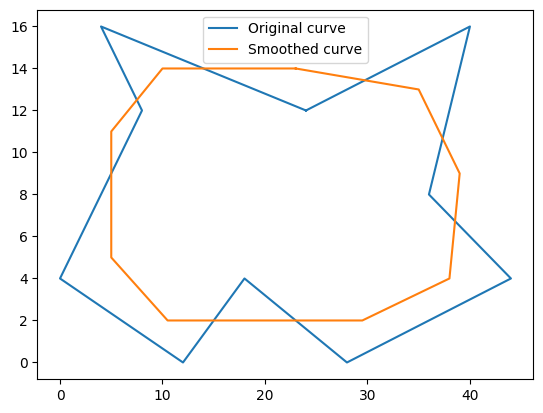

In [39]:
def smooth_curve(C, alpha):

    x = C[0]
    y = C[1]

    x_new = np.zeros(len(x))
    y_new = np.zeros(len(x))

    for i in range(len(x)):
        if i != len(x) - 1:
            x_new[i] = (1 - alpha)*x[i] + alpha * (x[i - 1] + x[i + 1]) / 2
            y_new[i] = (1 - alpha)*y[i] + alpha * (y[i - 1] + y[i + 1]) / 2
        else: 
            x_new[i] = (1 - alpha)*x[i] + alpha * (x[i - 1] + x[0]) / 2
            y_new[i] = (1 - alpha)*y[i] + alpha * (y[i - 1] + y[0]) / 2
    

    samlet = np.vstack((x_new, y_new))
    return samlet




C = np.array([
    [24, 40, 36, 44, 28, 18, 12, 0, 8, 4],
    [12, 16, 8, 4, 0, 4, 0, 4, 12, 16]
])
alpha = 0.5
S = smooth_curve(C,alpha)
print(S)

# Plotting the original and smoothed curve.
cycle = np.arange(C.shape[1] + 1)
cycle[-1] = 0 # Close the curve
plt.plot(C[0, cycle], C[1, cycle], label='Original curve')
plt.plot(S[0, cycle], S[1, cycle], label='Smoothed curve')
plt.legend()
plt.show()

In [52]:
def flowering_plants(G, m):
    g_trans = G.T
    start = g_trans[0]
    slut = g_trans[1]

    count = 0

    for s, s1 in zip(list(start), list(slut)):
        if s == 0 and s1 == 0:
            count += 1
        elif s == 12:
            if m == 12 or (1 <= m <= s1):
                count += 1

        elif s <= m <= s1:
            count += 1


    return count



G = np.array([[5, 9], [9, 11], [12, 6], [0, 0]])

print(flowering_plants(G, 6))


3


In [58]:
mylist = list(range(0,12))
mylist

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]